# AI Learning Navigator - Student Performance Analysis

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [3]:
df = pd.read_excel("student_learning_dataset.xlsx")

In [4]:
df.head(10)

,student_id,course_id,age,gender,ethnicity,study_time_weekly,absences,test_preparation,math_score,reading_score,writing_score,science_score,extracurricular,learning_style
0,1,C104,20,Male,Group C,13,2,Completed,99,96,83,86,Yes,Visual
1,2,C105,18,Male,Group B,13,12,Completed,86,100,68,85,No,Visual
2,3,C103,20,Male,Group A,9,2,NaN,83,82,87,67,Yes,Visual
3,4,C105,19,Male,Group C,15,2,Completed,96,100,100,100,No,Kinesthetic
4,5,C105,17,Male,Group B,12,2,NaN,89,77,83,81,Yes,Auditory
5,6,C102,20,Female,Group B,16,9,Completed,100,94,76,90,No,Visual
6,7,C103,17,Female,Group B,17,1,Completed,89,93,99,91,Yes,Auditory
7,8,C103,18,Female,Group C,6,4,NaN,74,73,89,68,Yes,Auditory
8,9,C103,17,Female,Group D,8,7,NaN,71,83,76,63,No,Auditory
9,10,C105,18,Female,Group C,15,3,Completed,85,95,100,88,No,Kinesthetic


In [5]:
print(df["test_preparation"].value_counts(dropna=False))

test_preparation
Completed    776
NaN          724
Name: count, dtype: int64


In [6]:
df["test_preparation"] = df["test_preparation"].fillna("Not Completed")
df["test_preparation"] = df["test_preparation"].str.lower()

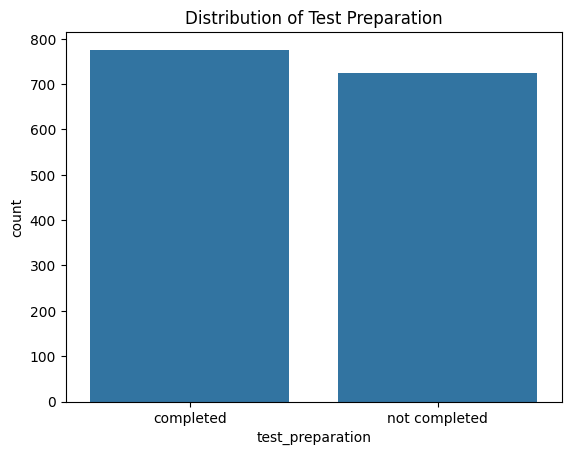

In [7]:
sns.countplot(x="test_preparation", data=df)
plt.title("Distribution of Test Preparation")
plt.show()

### **Distribution of Test Preparation**

**The dataset shows that a significant portion of students have not completed test preparation, while the rest have completed it. This indicates a clear variation in preparation levels among students.**

**Handling missing values as “Not Completed” reveals that many students may lack structured preparation, which can impact their academic performance. This highlights the importance of encouraging students to engage in preparation programs to improve outcomes.**

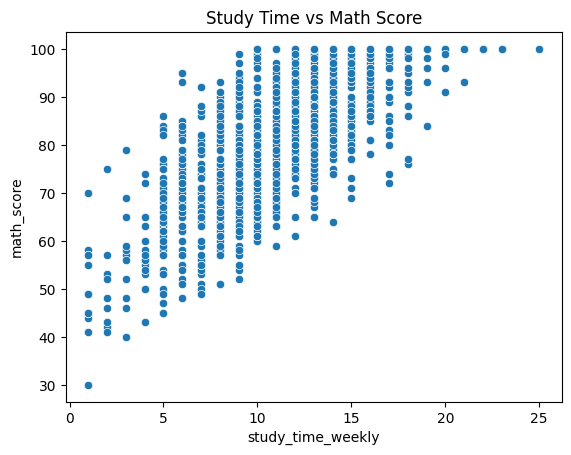

In [8]:
sns.scatterplot(x="study_time_weekly", y="math_score", data=df)
plt.title("Study Time vs Math Score")
plt.show()


### **Study Time and Academic Performance**

**Students who dedicate more hours to weekly study consistently achieve higher scores in mathematics. The positive relationship indicates that increased study time directly contributes to better understanding and performance. However, the improvement is gradual rather than extreme, suggesting that consistency matters more than short bursts of effort.**

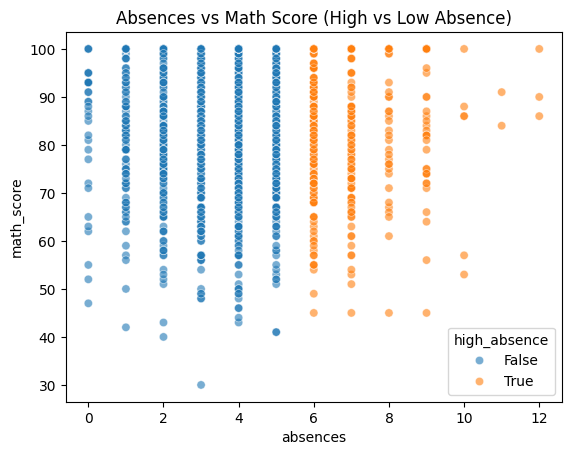

In [9]:
# create category
df["high_absence"] = df["absences"] > 5

sns.scatterplot(
    x="absences",
    y="math_score",
    hue="high_absence",
    data=df,
    alpha=0.6
)

plt.title("Absences vs Math Score (High vs Low Absence)")
plt.show()

### **Insight: Impact of Absences on Academic Performance**

**The relationship between absences and math scores appears to be weak and scattered, with no strong linear trend observed. While there is a slight negative tendency, the wide distribution of scores across different absence levels indicates that absences alone are not a strong predictor of student performance.**

**This suggests that although regular attendance contributes to stability, other factors such as study time and test preparation play a more significant role in determining academic outcomes.**

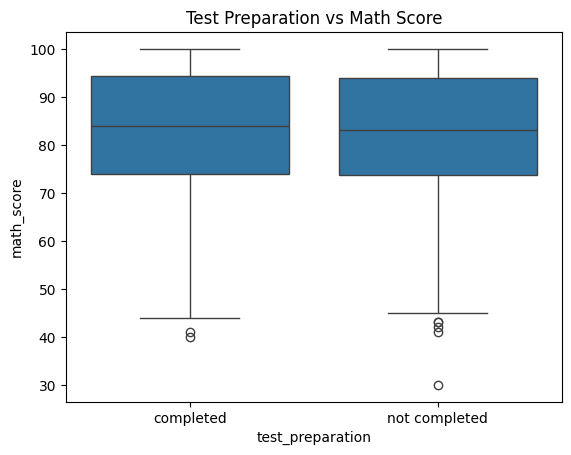

In [10]:
sns.boxplot(x="test_preparation", y="math_score", data=df)
plt.title("Test Preparation vs Math Score")
plt.show()

### **Role of Test Preparation**

**Students who have completed test preparation courses outperform those who have not. The difference in performance indicates that structured preparation helps reinforce concepts and improves exam readiness. This highlights the importance of guided learning in academic success.**

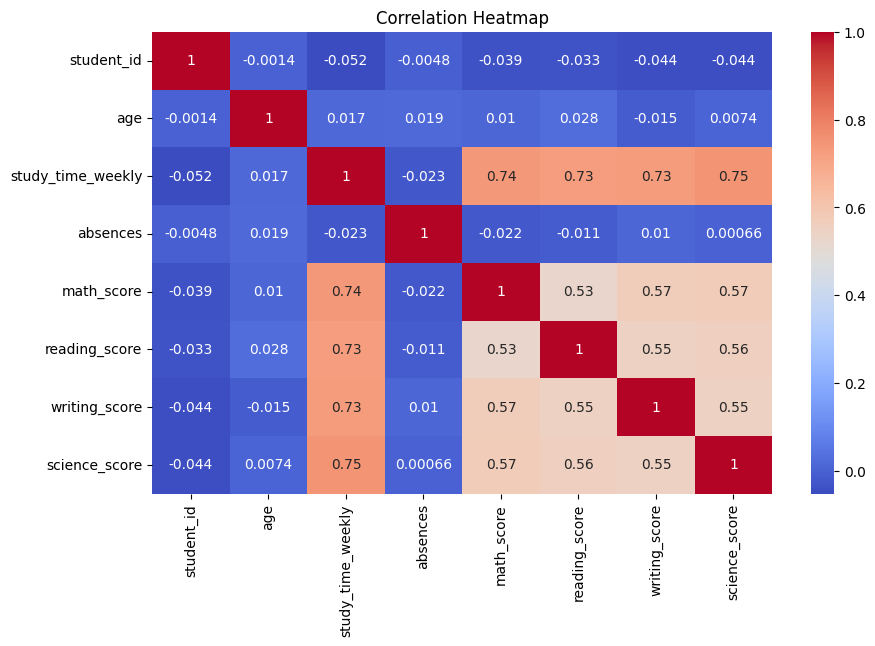

In [11]:
numeric_df = df.select_dtypes(include=["number"])
plt.figure(figsize=(10, 6))
sns.heatmap(numeric_df.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

### **Correlation Between Subjects**

**There is a strong positive correlation between reading and writing scores, indicating that students who perform well in one language-based subject tend to perform well in others. This suggests that language proficiency skills are interconnected and develop together.**

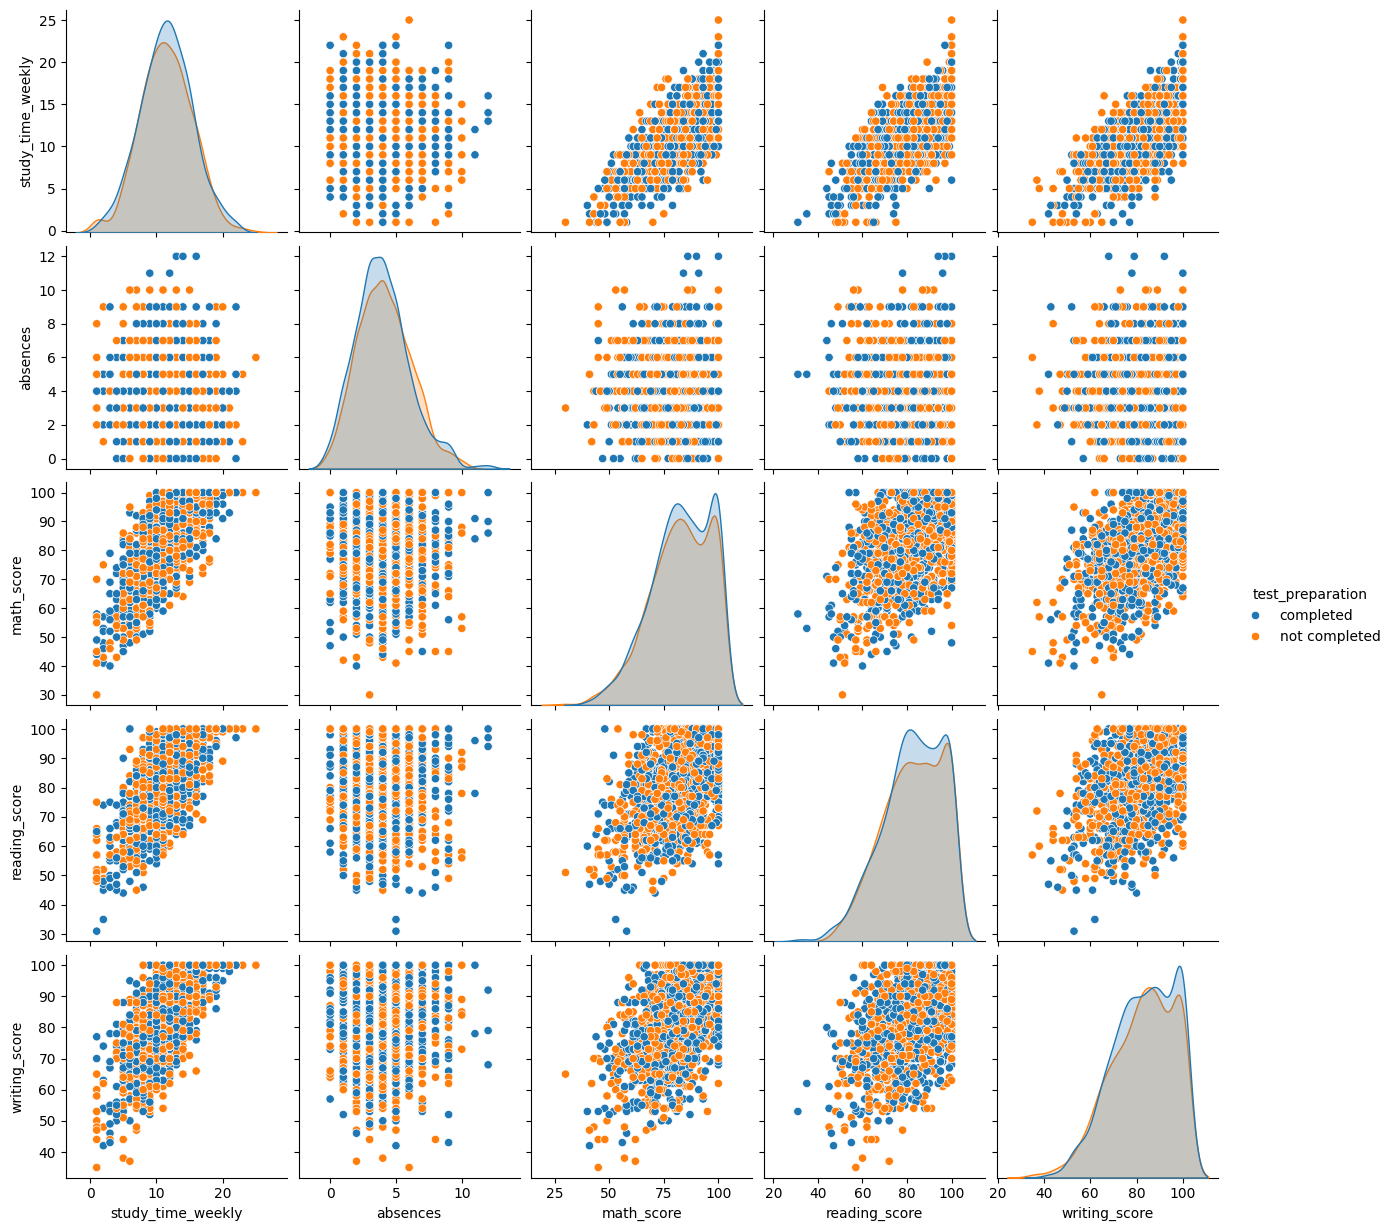

In [12]:
sns.pairplot(
    df,
    vars=["study_time_weekly", "absences", "math_score", "reading_score", "writing_score"],
    hue="test_preparation"
)
plt.show()

### **Insight: Multivariate Relationship Analysis Using Pairplot**

**The pairplot provides a comprehensive view of relationships between multiple variables in the dataset. It reveals that academic scores across subjects, such as math, reading, and writing, are positively correlated, indicating that students tend to perform consistently across different subjects.**

**Study time shows a clear positive relationship with performance, reinforcing its role in academic success.**

**Additionally, when colored by test preparation status, students who completed preparation tend to cluster toward higher score ranges, highlighting the importance of structured preparation in achieving better outcomes.**

In [13]:
def recommend(student):

    test_prep = student["test_preparation"]  # already cleaned earlier

    if student["math_score"] < 50 and student["absences"] > 10:
        return "High Risk: Improve attendance and review fundamentals"
    
    elif student["math_score"] < 50:
        return "Revise the basics and practice more questions"
    
    elif student["absences"] > 10:
        return "Reduce absences and maintain consistency"
    
    elif test_prep != "completed":
        return "Complete test preparation to improve performance"
    
    else:
        return "Keep up the good work and try advanced problems"

### **Insight: Personalized Recommendation Strategy**

**The recommendation system applies rule-based logic to generate personalized guidance for each student based on their academic performance, attendance, and preparation level. By combining multiple conditions, the system prioritizes identifying high-risk students who require immediate attention.**

**Students with both low scores and high absences are flagged as high-risk, indicating compounded academic and behavioral challenges. Those with low scores are advised to strengthen their fundamentals, while students with high absences are encouraged to improve consistency.**

**Additionally, students who have not completed test preparation are guided towards structured learning, highlighting its importance in improving outcomes. High-performing students receive suggestions to advance further, ensuring continuous development.**

**This approach demonstrates how simple rule-based systems can effectively transform raw data into actionable and personalized recommendations.**

In [14]:

df["recommendation"] = df.apply(recommend, axis=1)

print(df.head(5))


   student_id course_id  age gender ethnicity  study_time_weekly  absences  \
0           1      C104   20   Male   Group C                 13         2   
1           2      C105   18   Male   Group B                 13        12   
2           3      C103   20   Male   Group A                  9         2   
3           4      C105   19   Male   Group C                 15         2   
4           5      C105   17   Male   Group B                 12         2   

  test_preparation  math_score  reading_score  writing_score  science_score  \
0        completed          99             96             83             86   
1        completed          86            100             68             85   
2    not completed          83             82             87             67   
3        completed          96            100            100            100   
4    not completed          89             77             83             81   

  extracurricular learning_style  high_absence  \
0     

### **Insight: Recommendation Generation**

**The recommendation logic is applied to each student record to generate personalized suggestions based on performance, attendance, and preparation. This converts raw data into actionable insights, making the system practically useful.**

In [15]:
df[["math_score", "absences", "test_preparation", "recommendation"]].head(10)

,math_score,absences,test_preparation,recommendation
0,99,2,completed,Keep up the good work and try advanced problems
1,86,12,completed,Reduce absences and maintain consistency
2,83,2,not completed,Complete test preparation to improve performance
3,96,2,completed,Keep up the good work and try advanced problems
4,89,2,not completed,Complete test preparation to improve performance
5,100,9,completed,Keep up the good work and try advanced problems
6,89,1,completed,Keep up the good work and try advanced problems
7,74,4,not completed,Complete test preparation to improve performance
8,71,7,not completed,Complete test preparation to improve performance
9,85,3,completed,Keep up the good work and try advanced problems


### **Sample Recommendation Output**

**The table above demonstrates how the system generates personalized recommendations based on each student's academic performance, attendance, and preparation level. It highlights the practical application of the model in providing targeted guidance.**

### **Final Conclusion**

**The analysis shows that student performance is influenced by multiple factors, including study time, attendance, and test preparation. While study time and preparation have a strong positive impact, absences alone do not fully determine outcomes, indicating that performance is multi-dimensional.**

**The recommendation system effectively combines these factors to provide personalized guidance, making the solution practical for real-world academic improvement.**

**This demonstrates how data-driven insights can be translated into practical and scalable solutions for improving student outcomes.**

### **Student Segmentation using Clustering**

In [16]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

In [17]:
features = df[[
    "study_time_weekly",
    "absences",
    "math_score",
    "reading_score",
    "writing_score"
    ]]

In [18]:
scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)

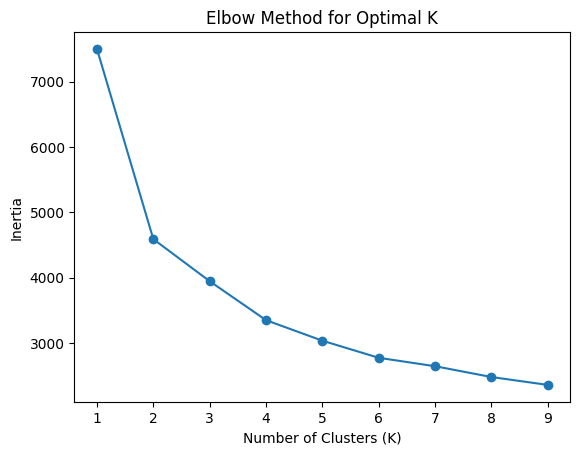

In [19]:
inertia = []
for k in range(1, 10):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(scaled_features)
    inertia.append(kmeans.inertia_)

plt.plot(range(1, 10), inertia, marker="o")
plt.title("Elbow Method for Optimal K")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.show()


In [20]:
kmeans = KMeans(n_clusters=3, random_state=42)
df["cluster"] = kmeans.fit_predict(scaled_features)
def label_cluster(cluster):
    if cluster == 0:
        return "Low Performer"
    elif cluster == 1:
        return "High Performer"
    else:
        return "Average (At Risk)"

df["performance_level"] = df["cluster"].apply(label_cluster)

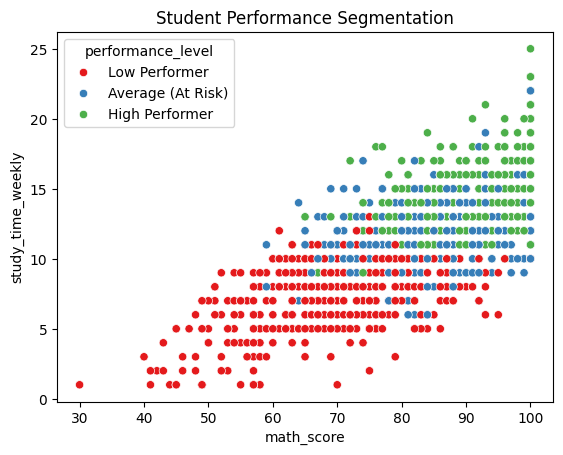

In [21]:
sns.scatterplot(
    x="math_score",
    y="study_time_weekly",
    hue="performance_level",
    data=df,
    palette="Set1",
    hue_order=["Low Performer", "Average (At Risk)", "High Performer"]
)

plt.title("Student Performance Segmentation")
plt.show()

In [22]:
df.groupby("cluster")[[
    "study_time_weekly",
    "absences",
    "math_score",
    "reading_score",
    "writing_score"
]].mean()

,study_time_weekly,absences,math_score,reading_score,writing_score
cluster,,,,,
0,7.567729,3.653386,70.274900,70.661355,69.878486
1,14.792208,3.005566,92.601113,91.918367,92.706865
2,11.864924,5.701525,84.575163,84.459695,85.577342


### **Student Performance Segmentation**

**The clustering visualization clearly separates students into three performance groups based on study habits and academic scores.**

**High performers demonstrate consistent study patterns and achieve top scores, while low performers show limited study engagement and lower academic outcomes.**

**The most critical group is the “Average (At Risk)” segment, which includes students with good potential but inconsistent study behavior. With targeted interventions such as improved attendance and structured preparation, these students can transition into high performers.**

**This segmentation enables focused and efficient strategies for improving overall student success.**

In [23]:
def final_action(row):

    if row["performance_level"] == "Low Performer":
        return "High Priority: Provide basic support, increase study time, and monitor progress closely"
    
    elif row["performance_level"] == "Average (At Risk)":
        return "Medium Priority: Improve consistency, reduce absences, and encourage regular practice"
    
    else:
        return "Low Priority: Encourage advanced learning and maintain performance"

In [24]:
df["action_plan"] = df.apply(final_action, axis=1)

In [27]:
def skill_gap(row):
    if row["math_score"] < 50:
        return "Weak Fundamentals"
    elif row["math_score"] < 75:
        return "Needs Improvement"
    else:
        return "Strong"

df["skill_gap"] = df.apply(skill_gap, axis=1)

### **Student Segmentation Summary**
The clustering analysis successfully segments students into three distinct groups based on study behavior and academic performance: Low Performers, Average (At Risk), and High Performers.

High performers demonstrate strong study habits and consistent academic results, while low performers show limited engagement and weaker outcomes.

The most critical group is the “Average (At Risk)” segment, which includes students with strong potential but inconsistent behavior, particularly higher absences. This group represents the highest opportunity for targeted intervention.

In [28]:
def learning_path(row):

    if row["performance_level"] == "Low Performer":
        return "Start with basic concepts, focus on fundamentals, and daily practice"

    elif row["performance_level"] == "Average (At Risk)":
        return "Follow structured learning plan, reduce absences, and solve practice sets"

    else:
        return "Advance to complex problems, real-world applications, and skill development"


df["learning_path"] = df.apply(learning_path, axis=1)

The system generates personalized learning paths based on student performance and behavior patterns.

Low-performing students are guided towards strengthening fundamentals, average students are encouraged to improve consistency and practice regularly, while high-performing students are directed towards advanced problem-solving and real-world applications.

This ensures that learning is adaptive rather than one-size-fits-all.

In [36]:
def career_alignment(row):

    if row["performance_level"] == "High Performer" and row["math_score"] > 85:
        return "Suitable for Data Science / Engineering roles"
    
    elif row["performance_level"] == "Average (At Risk)":
        return "Needs consistency before moving to advanced career paths"

    elif row["math_score"] > 70:
        return "Suitable for Analytical and Technical roles"

    else:
        return "Focus on foundational skills before specialization"


df["career_path"] = df.apply(career_alignment, axis=1)

Career recommendations are not based solely on academic scores but also consider behavioral consistency and engagement patterns.

Students with high scores but inconsistent performance are advised to improve stability before pursuing advanced career paths, while consistently high-performing students are aligned with roles such as Data Science and Engineering.

This reflects a more realistic and practical approach to career guidance.

In [37]:
print(df[[
    "math_score",
    "performance_level",
    "skill_gap",
    "learning_path",
    "career_path",
    "action_plan"
]].head(5))

   math_score  performance_level skill_gap  \
0          99     High Performer    Strong   
1          86  Average (At Risk)    Strong   
2          83     High Performer    Strong   
3          96     High Performer    Strong   
4          89     High Performer    Strong   

                                       learning_path  \
0  Advance to complex problems, real-world applic...   
1  Follow structured learning plan, reduce absenc...   
2  Advance to complex problems, real-world applic...   
3  Advance to complex problems, real-world applic...   
4  Advance to complex problems, real-world applic...   

                                         career_path  \
0      Suitable for Data Science / Engineering roles   
1  Needs consistency before moving to advanced ca...   
2        Suitable for Analytical and Technical roles   
3      Suitable for Data Science / Engineering roles   
4      Suitable for Data Science / Engineering roles   

                                         action_p

### **AI-Based Intervention Strategy**

By integrating clustering, recommendation logic, skill gap analysis, and career alignment, the system evolves into a comprehensive decision-making framework.

Instead of merely analyzing data, the system translates insights into actionable strategies, making it suitable for real-world educational environments.

In [ ]:
df["performance_level"].value_counts()

performance_level
High Performer       539
Low Performer        502
Average (At Risk)    459
Name: count, dtype: int64

### **Key Insight: The Role of Consistency in Student Performance**

The analysis reveals that student performance is multi-dimensional and influenced by a combination of study habits, attendance, and preparation.

Notably, consistency plays a more critical role than raw performance scores, highlighting that students with good potential can underperform due to irregular engagement.

This insight emphasizes the importance of behavioral factors in academic success.

### **Final Conclusion**

The project demonstrates that student performance cannot be evaluated using a single metric, as it is influenced by multiple factors such as study habits, attendance, and preparation.

By integrating clustering, personalized recommendations, skill gap analysis, and career alignment, the system transforms raw academic data into meaningful and actionable insights.

The identification of the “Average (At Risk)” group highlights a critical opportunity area, where targeted interventions can significantly improve outcomes.

Overall, this project showcases how AI-driven approaches can move beyond traditional analysis and enable personalized, scalable, and practical solutions in modern education systems.